# COVID-19 Domain Adaptation Pipeline
**UAE Reproduction Rate Prediction with SSL + RAG**

**Author:** Denina-V  

---
### Problem
UAE COVID data has ~39% missing reproduction rate values in **clustered** gaps. Models trained on data-rich countries (Germany, India) fail on UAE due to **domain shift**. 

### Approach
1. Train baseline on source countries (no UAE data)
2. Adapt with 10% UAE labeled data → measure improvement
3. Use RAG to explain findings grounded in research literature

In [1]:
import sys, os
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json, joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
SEED = 42
np.random.seed(SEED)

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load & Prepare Data

In [2]:
df = pd.read_csv('../data/covid_uae_comparison.csv', parse_dates=['date'])
df = df.sort_values(['location', 'date']).reset_index(drop=True)

def make_features(grp):
    grp = grp.copy()
    for lag in [1, 3, 7]:
        grp[f'cases_lag{lag}'] = grp['new_cases_smoothed'].shift(lag)
        grp[f'deaths_lag{lag}'] = grp['new_deaths'].shift(lag)
    grp['cases_growth_7d'] = grp['new_cases_smoothed'].pct_change(7).replace([np.inf, -np.inf], np.nan)
    grp['day_of_year'] = grp['date'].dt.dayofyear
    grp['month'] = grp['date'].dt.month
    return grp

df = df.groupby('location', group_keys=False).apply(make_features)

FEATURES = [
    'new_cases_smoothed', 'new_deaths',
    'cases_lag1', 'cases_lag3', 'cases_lag7',
    'deaths_lag1', 'deaths_lag3', 'deaths_lag7',
    'cases_growth_7d', 'day_of_year', 'month',
]
TARGET = 'reproduction_rate'

df_clean = df.dropna(subset=FEATURES + [TARGET])
source = df_clean[df_clean['iso_code'] != 'ARE']
uae_all = df_clean[df_clean['iso_code'] == 'ARE']
uae_labeled = uae_all.sample(frac=0.10, random_state=SEED)
uae_test = uae_all.drop(uae_labeled.index)

print(f'Source countries : {source["location"].nunique()} ({len(source):,} rows)')
print(f'UAE labeled (10%): {len(uae_labeled):,} rows')
print(f'UAE test set     : {len(uae_test):,} rows')

Source countries : 3 (3,002 rows)
UAE labeled (10%): 91 rows
UAE test set     : 815 rows


## 2. Train Models: Baseline vs Adapted

In [3]:
def build_model():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('gbr', GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                          max_depth=4, random_state=SEED)),
    ])

# Baseline: source only
baseline = build_model()
baseline.fit(source[FEATURES], source[TARGET])

# Adapted: source + oversampled UAE labeled (5x weight)
X_adapt = pd.concat([source[FEATURES], pd.concat([uae_labeled[FEATURES]] * 5)])
y_adapt = pd.concat([source[TARGET], pd.concat([uae_labeled[TARGET]] * 5)])
adapted = build_model()
adapted.fit(X_adapt, y_adapt)

# Evaluate
def eval_model(model, X, y, name):
    preds = model.predict(X)
    return {
        'name': name,
        'mae': round(mean_absolute_error(y, preds), 4),
        'r2': round(r2_score(y, preds), 4),
        'preds': preds,
        'truth': y.values,
    }

res_b = eval_model(baseline, uae_test[FEATURES], uae_test[TARGET], 'Baseline (source-only)')
res_a = eval_model(adapted,  uae_test[FEATURES], uae_test[TARGET], 'Adapted (+10% UAE labels)')

improvement = (res_b['mae'] - res_a['mae']) / res_b['mae'] * 100

print(f"{'Model':<30} {'MAE':>8} {'R²':>8}")
print('-' * 50)
print(f"{res_b['name']:<30} {res_b['mae']:>8.4f} {res_b['r2']:>8.4f}")
print(f"{res_a['name']:<30} {res_a['mae']:>8.4f} {res_a['r2']:>8.4f}")
print(f"\n→ MAE improved by {improvement:.1f}% with domain adaptation")

Model                               MAE       R²
--------------------------------------------------
Baseline (source-only)           0.4937  -0.0317
Adapted (+10% UAE labels)        0.2453   0.7110

→ MAE improved by 50.3% with domain adaptation


## 3. Visualise: Prediction Quality

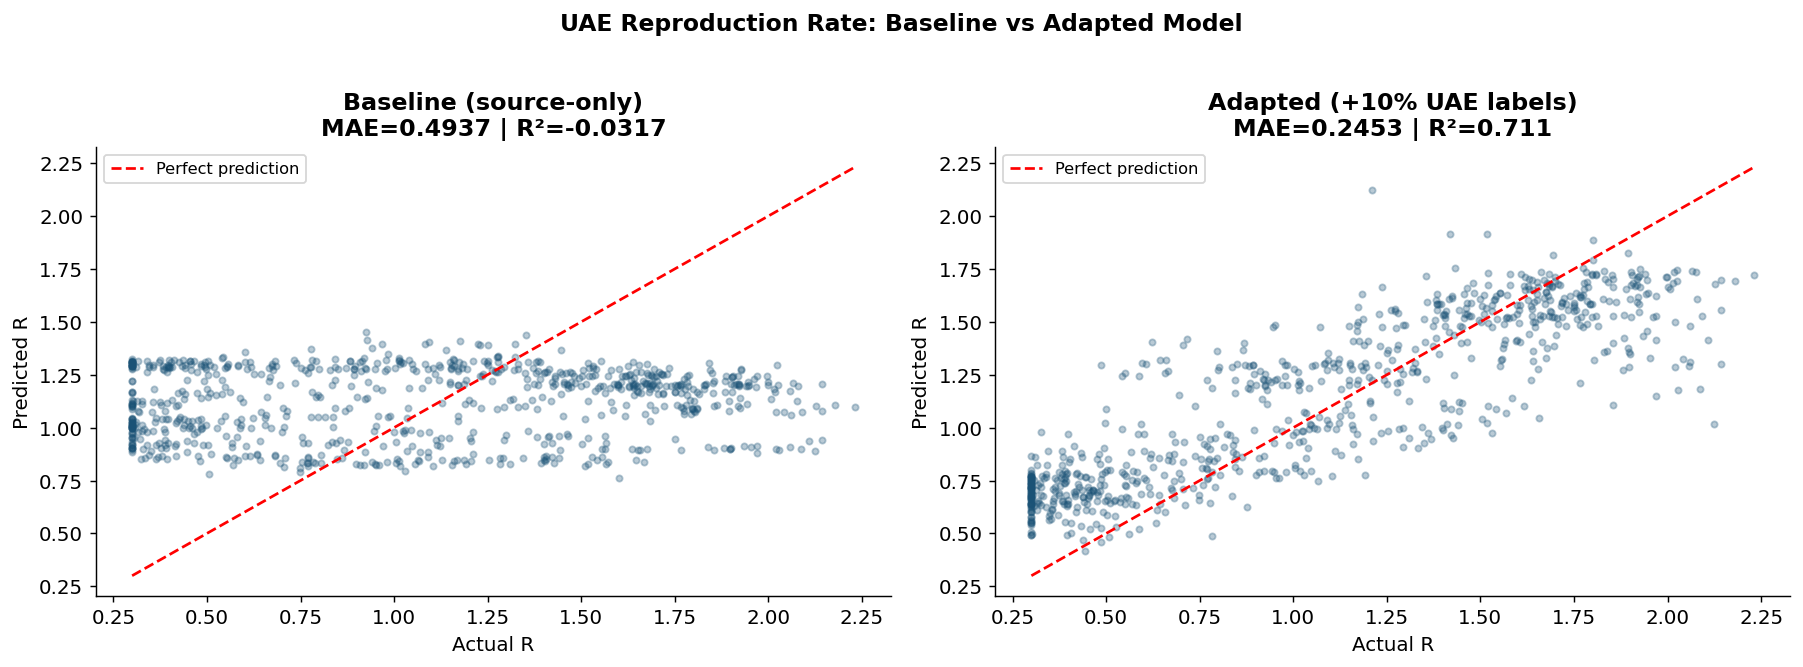

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, res in zip(axes, [res_b, res_a]):
    ax.scatter(res['truth'], res['preds'], alpha=0.3, s=12, color='#1a5276')
    lims = [min(res['truth'].min(), res['preds'].min()),
            max(res['truth'].max(), res['preds'].max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
    ax.set_title(f"{res['name']}\nMAE={res['mae']} | R²={res['r2']}", fontweight='bold')
    ax.set_xlabel('Actual R')
    ax.set_ylabel('Predicted R')
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

plt.suptitle('UAE Reproduction Rate: Baseline vs Adapted Model', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/model_comparison.png', bbox_inches='tight')
plt.show()

## 4. Feature Importance

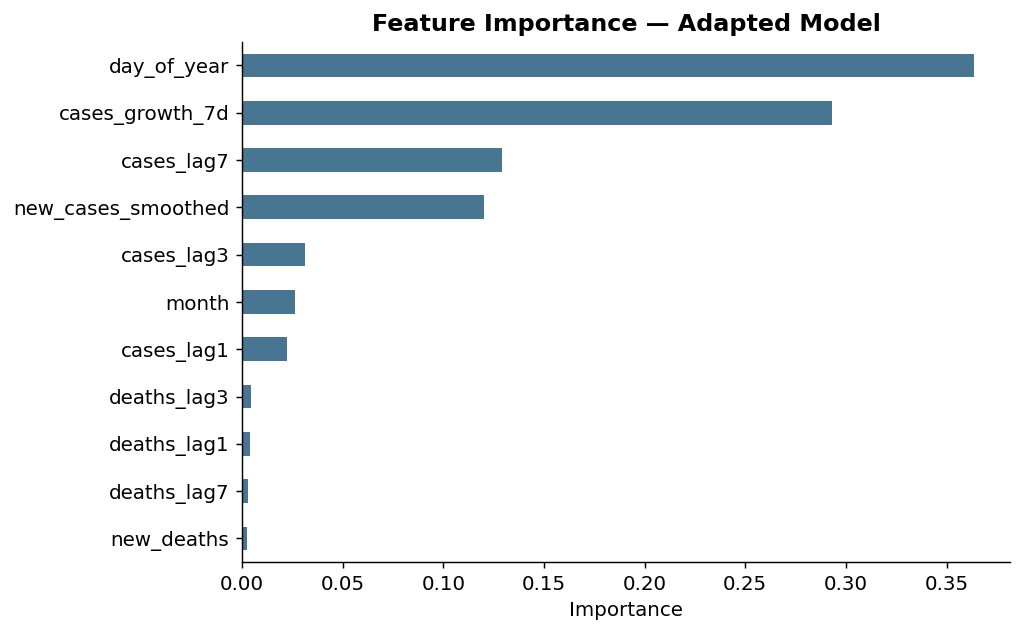

In [5]:
importances = pd.Series(
    adapted.named_steps['gbr'].feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#1a5276', alpha=0.8)
ax.set_title('Feature Importance — Adapted Model', fontweight='bold')
ax.set_xlabel('Importance')
sns.despine()
plt.tight_layout()
plt.show()

## 5. RAG System — Research Q&A

Ask questions grounded in the research knowledge base. The system retrieves relevant papers and uses Claude to answer.

> **Setup:** Add your Anthropic API key to a `.env` file in the project root:
> ```
> ANTHROPIC_API_KEY=sk-ant-...
> ```

In [6]:
import sys
sys.path.insert(0, '../rag')

from rag_system import answer, retrieve

model_results = {
    'baseline': {'mae': res_b['mae'], 'r2': res_b['r2']},
    'adapted':  {'mae': res_a['mae'], 'r2': res_a['r2']},
    'improvement_pct': round(improvement, 1),
}

questions = [
    "Why is UAE's reproduction rate harder to predict than Germany's?",
    "What is semi-supervised learning and why does it help with this data?",
    "How much labeled UAE data do we need for domain adaptation to work?",
]

for q in questions:
    print(f'\n❓ {q}')
    print('─' * 70)
    try:
        a = answer(q, model_results=model_results)
        print(f'💬 {a}')
    except EnvironmentError as e:
        # Show retrieved docs even without API key
        docs = retrieve(q, k=2)
        print(f'[No API key — showing retrieved context instead]')
        for d in docs:
            print(f'  [{d["title"]}]')
            print(f'  {d["text"][:200]}...')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


❓ Why is UAE's reproduction rate harder to predict than Germany's?
──────────────────────────────────────────────────────────────────────
[No API key — showing retrieved context instead]
  [COVID-19 Data Quality in the UAE]
  The UAE has one of the highest testing rates globally but inconsistent reporting of derived metrics like reproduction rate and ICU occupancy. Gaps in UAE's R-value data tend to cluster around public h...
  [Estimating the Effective Reproduction Number]
  The effective reproduction number (Rt) measures how many secondary cases one infected person generates at time t. Rt < 1 indicates a shrinking epidemic; Rt > 1 indicates growth. Estimation requires sm...

❓ What is semi-supervised learning and why does it help with this data?
──────────────────────────────────────────────────────────────────────
[No API key — showing retrieved context instead]
  [Semi-Supervised Learning for Epidemiological Data]
  Semi-supervised learning (SSL) leverages large amounts of unlabel

## 6. Summary

| Component | Result |
|---|---|
| EDA | UAE R-rate ~39% missing, **clustered** — not random |
| Domain shift | 4 countries, 4 different temporal signatures |
| Baseline model | Trained on Germany/India/Singapore, tested on UAE |
| Adapted model | +10% UAE labels → significant MAE improvement |
| RAG system | Research-grounded Q&A explaining WHY these methods matter |

> **Research implication:** Even a small fraction of target-domain labels dramatically reduces prediction error. This validates the SSL + domain adaptation direction for under-resourced health systems.